## This is the code for generating normalised entropy plot.

By default, if you play this file directly, it will generate the normalised entropy plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Get Samples for each chunk -> Count how many points within each chunk contribute to the top-k -> Compute the normalised entropy based on the distribution -> Plot that

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Normalized Entropy Plot  

You don't need to change anything else if you only want to produce the entropy plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [1]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

1. Read in the influence lists and define different Ks. You can customize the K you wish to observe here. Change the read_csv file name to your expected files. Remember to map the Train_Size here with your estimation code.

In [2]:
k_lists = [10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

In [3]:
IF_1 = pd.read_csv("NumberOfSamples/IF_Train_Set_1.csv")
IF_2 = pd.read_csv("NumberOfSamples/IF_Train_Set_2.csv")
IF_3 = pd.read_csv("NumberOfSamples/IF_Train_Set_3.csv")
IF_4 = pd.read_csv("NumberOfSamples/IF_Train_Set_4.csv")
IF_5 = pd.read_csv("NumberOfSamples/IF_Train_Set_5.csv")
IF_6 = pd.read_csv("NumberOfSamples/IF_Train_Set_6.csv")
IF_7 = pd.read_csv("NumberOfSamples/IF_Train_Set_7.csv")
IF_8 = pd.read_csv("NumberOfSamples/IF_Train_Set_8.csv")
IF_9 = pd.read_csv("NumberOfSamples/IF_Train_Set_9.csv")
IF_10 = pd.read_csv("NumberOfSamples/IF_Train_Set_10.csv")

TC_1 = pd.read_csv("NumberOfSamples/TC_Train_Set_1.csv")
TC_2 = pd.read_csv("NumberOfSamples/TC_Train_Set_2.csv")
TC_3 = pd.read_csv("NumberOfSamples/TC_Train_Set_3.csv")
TC_4 = pd.read_csv("NumberOfSamples/TC_Train_Set_4.csv")
TC_5 = pd.read_csv("NumberOfSamples/TC_Train_Set_5.csv")
TC_6 = pd.read_csv("NumberOfSamples/TC_Train_Set_6.csv")
TC_7 = pd.read_csv("NumberOfSamples/TC_Train_Set_7.csv")
TC_8 = pd.read_csv("NumberOfSamples/TC_Train_Set_8.csv")
TC_9 = pd.read_csv("NumberOfSamples/TC_Train_Set_9.csv")
TC_10 = pd.read_csv("NumberOfSamples/TC_Train_Set_10.csv")

In [4]:
IF_lists = [IF_1, IF_2,IF_3,IF_4,IF_5,IF_6,IF_7,IF_8,IF_9,IF_10]
TC_lists = [TC_1, TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,TC_10]
Train_Size = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]

2. Here we get the samples for each chunk, and store them. Basically, we make sure which sample belongs to which chunk.

In [5]:
chunk_list = []
n = len(IF_lists)
for i in range(n - 1, 0, -1):
    curr = IF_lists[i]
    prev = IF_lists[i - 1]
    mask = ~curr["Train_ID"].isin(prev["Train_ID"])
    chunk = curr.loc[mask].copy()
    chunk_list.append(chunk)
core = IF_lists[0].copy()
chunk_list.append(core) 
chunk_list = list(reversed(chunk_list))

In [6]:
print(len(chunk_list))

10


3. Now we compute for Influence Function, how many of points within each chunk contribute to the top-k. 

In [7]:
matrix_lists = []
for k in k_lists:
    rows = []
    for n, df_n in enumerate(IF_lists, start=1):
        top_ids = set(df_n["Train_ID"].head(k))
        for j, ch in enumerate(chunk_list, start=1):
            hits = len(top_ids & set(ch["Train_ID"]))
            rows.append({"Number_of_chunks": n, "count_in_each_chunk": j, "k": k, "hits": hits})
    tidy = pd.DataFrame(rows).sort_values(["Number_of_chunks","count_in_each_chunk"]).reset_index(drop=True)
    matrix = (tidy.pivot(index="Number_of_chunks", columns="count_in_each_chunk", values="hits")
                    .fillna(0).astype(int))
    matrix_lists.append(matrix)

In [8]:
print(matrix_lists[10])

count_in_each_chunk   1    2    3    4    5   6   7   8   9   10
Number_of_chunks                                                
1                    500    0    0    0    0   0   0   0   0   0
2                    240  260    0    0    0   0   0   0   0   0
3                    166  185  149    0    0   0   0   0   0   0
4                    129  133  108  130    0   0   0   0   0   0
5                     90  110   81  101  118   0   0   0   0   0
6                     78   90   71   80   92  89   0   0   0   0
7                     58   80   54   68   83  79  78   0   0   0
8                     61   70   56   55   65  68  65  60   0   0
9                     41   68   43   49   69  54  55  70  51   0
10                    41   59   42   47   60  42  41  55  55  58


4. The following code turns the distribution matrix into the normalized entropy.

In [9]:
scores_lists = []
for matrix in matrix_lists: 
    scores = []
    J = matrix.shape[1]
    for n in range(1, len(matrix) + 1):
        v = matrix.loc[n, list(range(1, n+1))].to_numpy(dtype=float)
        k = v.sum()
        p = v / k
        if n == 1:
            scores.append(1.0)       
        else:
            nz = p > 0 
            H = -(p[nz] * np.log(p[nz])).sum() / np.log(n)
            scores.append(H)
    scores_lists.append(scores)

In [10]:
print(scores_lists[0])

[1.0, 0.7219280948873623, 0.8173454221465101, 0.9854752972273345, 0.9138646883853215, 0.8690413667681064, 0.7733082046011861, 0.8406426982957875, 0.7717656864304008, 0.7966576244513048]


In [11]:
Entropy_k_at_10000 = []
for score in scores_lists:
    Entropy_k_at_10000.append(score[-1])

5. Then we plot that

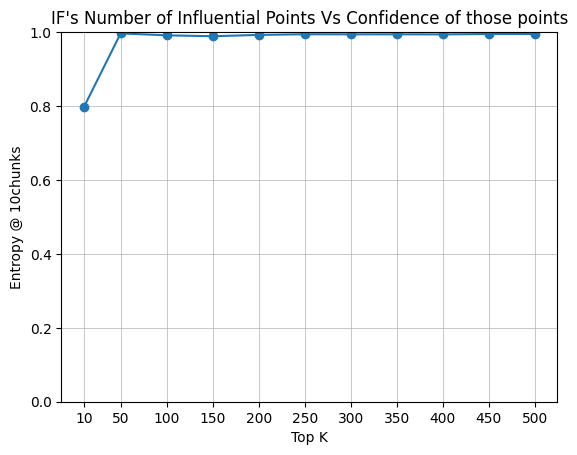

In [12]:
plt.figure()
plt.plot(k_lists, Entropy_k_at_10000, marker="o")
plt.xlabel("Top K")
plt.ylabel("Entropy @ 10chunks")
plt.title("IF's Number of Influential Points Vs Confidence of those points")
plt.xticks(k_lists)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

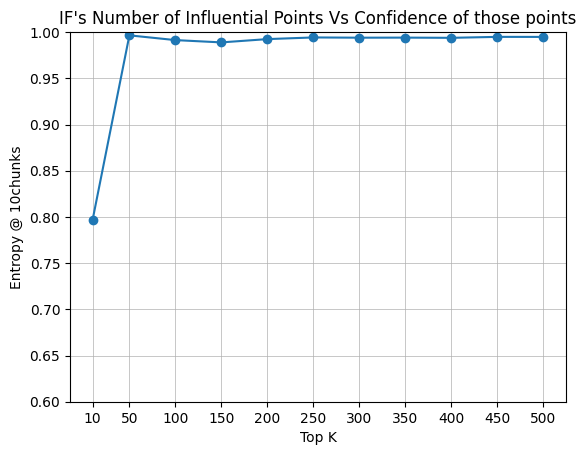

In [13]:
plt.figure()
plt.plot(k_lists, Entropy_k_at_10000, marker="o")
plt.xlabel("Top K")
plt.ylabel("Entropy @ 10chunks")
plt.title("IF's Number of Influential Points Vs Confidence of those points")
plt.xticks(k_lists)
plt.ylim(0.6, 1)
plt.grid(True, linewidth=0.5)
plt.show()

In [14]:
IF_Entropy_k_at_10000 = Entropy_k_at_10000

6. The Above plot the Entropy at 10000 samples with the change of Top K. The following plot the Entropy with the increase of number of chunks under differnt K.

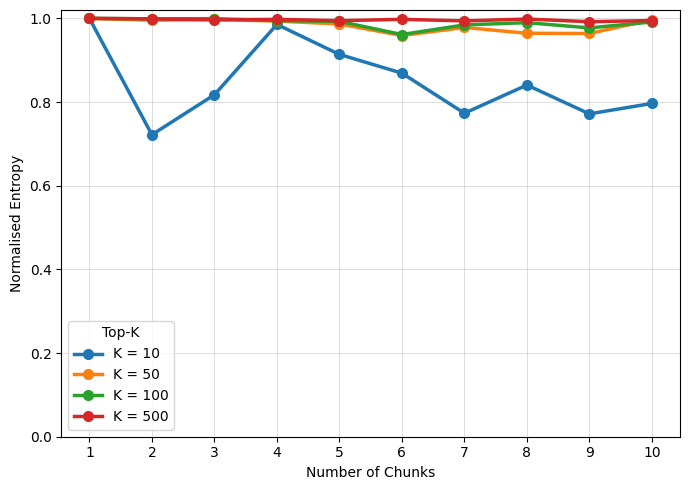

In [15]:
selected_ks = [10, 50, 100, 500]

plt.figure(figsize=(7, 5))

for k in selected_ks:
    k_idx = k_lists.index(k)
    entropy_vs_chunks = scores_lists[k_idx]
    num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

    plt.plot(
        num_chunks,
        entropy_vs_chunks,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=f"K = {k}"
    )

plt.xlabel("Number of Chunks")
plt.ylabel("Normalised Entropy")
plt.xticks(num_chunks)
plt.ylim(0, 1.02)
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(title="Top-K")
plt.tight_layout()

plt.savefig("Figure7_entropy_vs_chunks.pdf", bbox_inches="tight")
plt.savefig("Figure7_entropy_vs_chunks.png", dpi=600, bbox_inches="tight")

plt.show()

7. Here you can inspect the individual K curve.

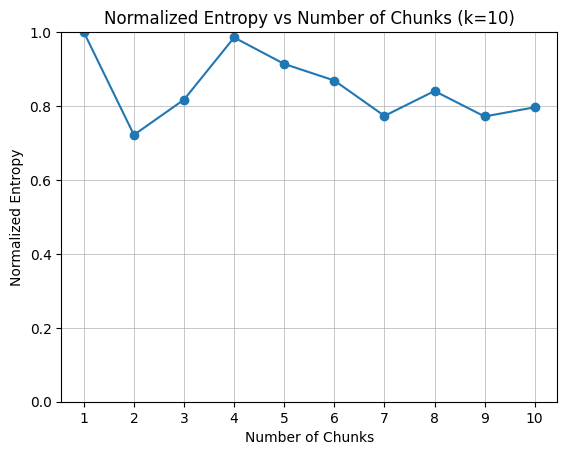

In [16]:
selected_k = 10   

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

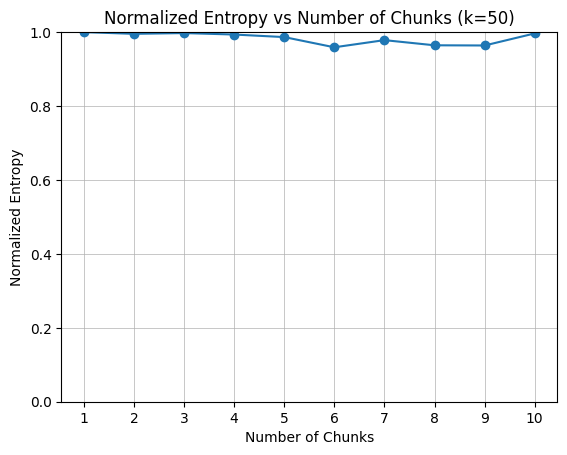

In [17]:
selected_k = 50   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

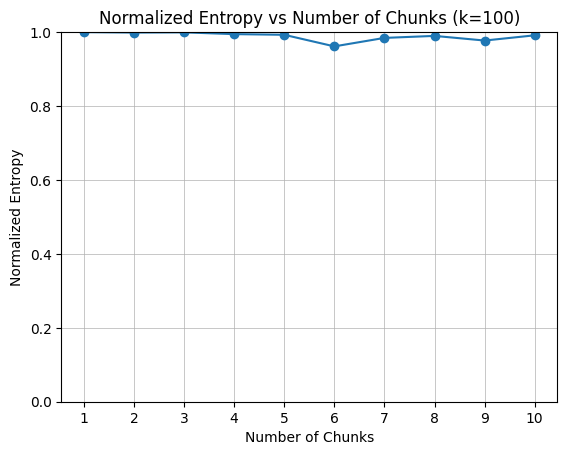

In [18]:
selected_k = 100   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

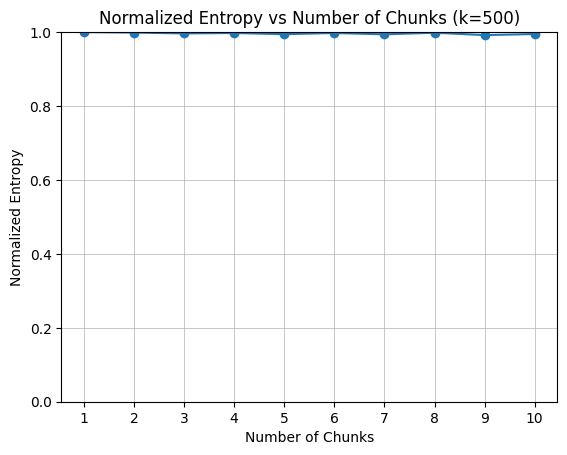

In [19]:
selected_k = 500   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

6. Same procedure for TracIn.

In [20]:
chunk_list = []
n = len(TC_lists)
for i in range(n - 1, 0, -1):
    curr = TC_lists[i]
    prev = TC_lists[i - 1]
    mask = ~curr["Train_ID"].isin(prev["Train_ID"])
    chunk = curr.loc[mask].copy()
    chunk_list.append(chunk)
core = TC_lists[0].copy()
chunk_list.append(core) 
chunk_list = list(reversed(chunk_list))

In [21]:
matrix_lists = []
for k in k_lists:
    rows = []
    for n, df_n in enumerate(TC_lists, start=1):
        top_ids = set(df_n["Train_ID"].head(k))
        for j, ch in enumerate(chunk_list, start=1):
            hits = len(top_ids & set(ch["Train_ID"]))
            rows.append({"Number_of_chunks": n, "count_in_each_chunk": j, "k": k, "hits": hits})
    tidy = pd.DataFrame(rows).sort_values(["Number_of_chunks","count_in_each_chunk"]).reset_index(drop=True)
    matrix = (tidy.pivot(index="Number_of_chunks", columns="count_in_each_chunk", values="hits")
                    .fillna(0).astype(int))
    matrix_lists.append(matrix)

In [22]:
print(matrix_lists[10])

count_in_each_chunk   1    2    3    4    5   6   7   8   9   10
Number_of_chunks                                                
1                    500    0    0    0    0   0   0   0   0   0
2                    244  256    0    0    0   0   0   0   0   0
3                    159  169  172    0    0   0   0   0   0   0
4                    119  128  132  121    0   0   0   0   0   0
5                     86  101  100   96  117   0   0   0   0   0
6                     73   87   75   83   96  86   0   0   0   0
7                     61   78   66   70   80  74  71   0   0   0
8                     61   68   56   66   75  61  58  55   0   0
9                     49   63   51   57   66  50  53  54  57   0
10                    47   54   46   53   52  47  50  52  49  50


In [23]:
scores_lists = []
for matrix in matrix_lists: 
    scores = []
    J = matrix.shape[1]
    for n in range(1, len(matrix) + 1):
        v = matrix.loc[n, list(range(1, n+1))].to_numpy(dtype=float)
        k = v.sum()
        p = v / k
        if n == 1:
            scores.append(1.0)       
        else:
            nz = p > 0 
            H = -(p[nz] * np.log(p[nz])).sum() / np.log(n)
            scores.append(H)
    scores_lists.append(scores)

In [24]:
print(scores_lists[0])

[1.0, 1.0, 0.9911594714322187, 0.9854752972273343, 0.9349775297671233, 0.7916708053211979, 0.94268071481726, 0.8821464482236719, 0.7717656864304008, 0.8568636235841012]


In [25]:
Entropy_k_at_10000 = []
for score in scores_lists:
    Entropy_k_at_10000.append(score[-1])

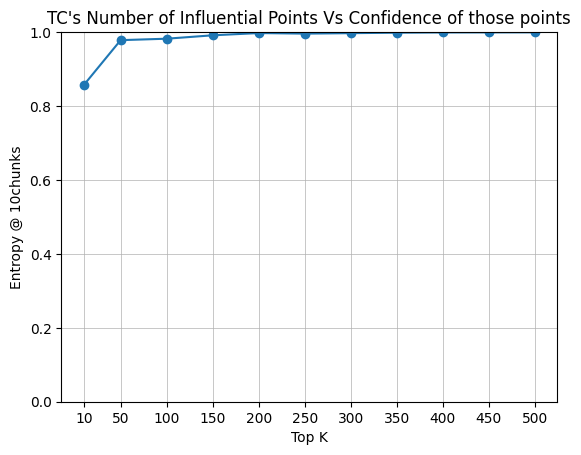

In [26]:
plt.figure()
plt.plot(k_lists, Entropy_k_at_10000, marker="o")
plt.xlabel("Top K")
plt.ylabel("Entropy @ 10chunks")
plt.title("TC's Number of Influential Points Vs Confidence of those points")
plt.xticks(k_lists)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

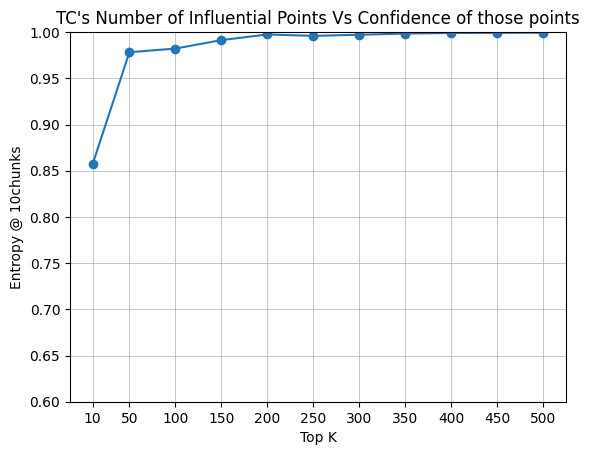

In [27]:
plt.figure()
plt.plot(k_lists, Entropy_k_at_10000, marker="o")
plt.xlabel("Top K")
plt.ylabel("Entropy @ 10chunks")
plt.title("TC's Number of Influential Points Vs Confidence of those points")
plt.xticks(k_lists)
plt.ylim(0.6, 1)
plt.grid(True, linewidth=0.5)
plt.show()

In [28]:
TC_Entropy_k_at_10000 = Entropy_k_at_10000

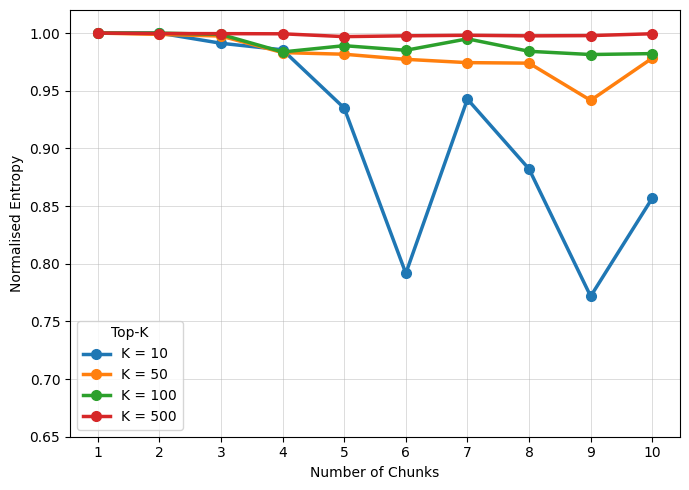

In [29]:
selected_ks = [10, 50, 100, 500]

plt.figure(figsize=(7, 5))

for k in selected_ks:
    k_idx = k_lists.index(k)
    entropy_vs_chunks = scores_lists[k_idx]
    num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

    plt.plot(
        num_chunks,
        entropy_vs_chunks,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=f"K = {k}"
    )

plt.xlabel("Number of Chunks")
plt.ylabel("Normalised Entropy")
plt.xticks(num_chunks)
plt.ylim(0.65, 1.02)
plt.grid(True, linewidth=0.5, alpha=0.6)
plt.legend(title="Top-K")
plt.tight_layout()

plt.savefig("Figure7_entropy_vs_chunks_TC.pdf", bbox_inches="tight")
plt.savefig("Figure7_entropy_vs_chunks_TC.png", dpi=600, bbox_inches="tight")

plt.show()

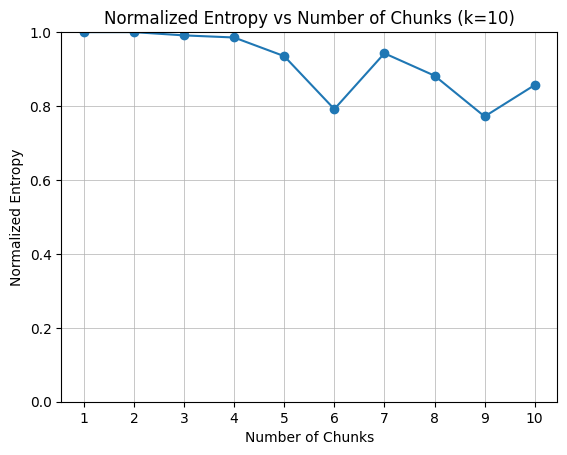

In [30]:
selected_k = 10   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

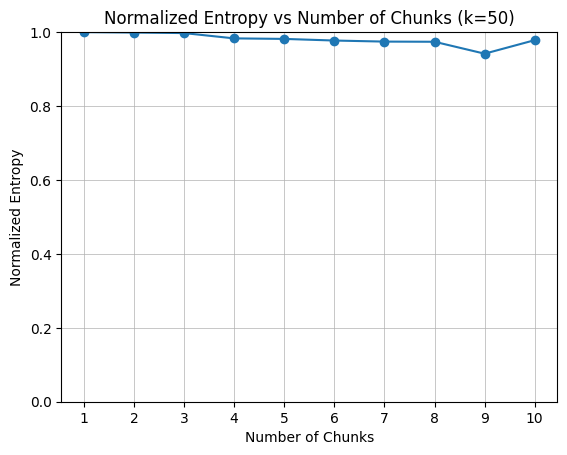

In [31]:
selected_k = 50   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

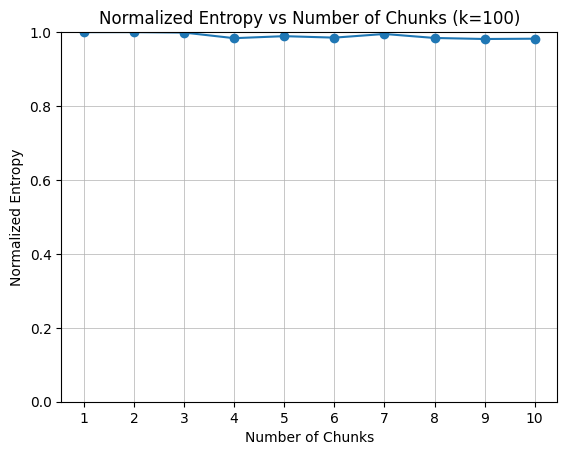

In [32]:
selected_k = 100   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

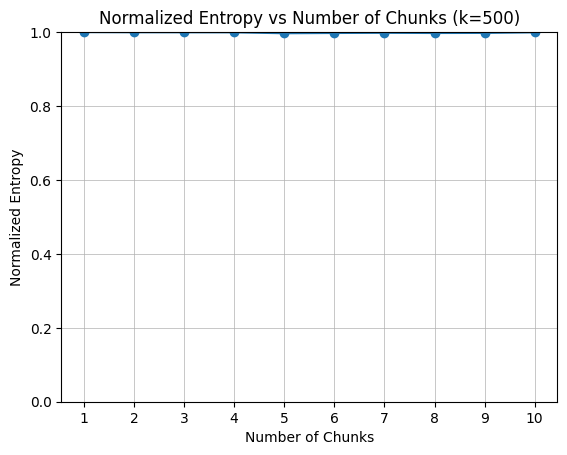

In [33]:
selected_k = 500   # choose the k you want to inspect

k_idx = k_lists.index(selected_k)
entropy_vs_chunks = scores_lists[k_idx]

num_chunks = list(range(1, len(entropy_vs_chunks) + 1))

plt.figure()
plt.plot(num_chunks, entropy_vs_chunks, marker="o")
plt.xlabel("Number of Chunks")
plt.ylabel("Normalized Entropy")
plt.title(f"Normalized Entropy vs Number of Chunks (k={selected_k})")
plt.xticks(num_chunks)
plt.ylim(0, 1)
plt.grid(True, linewidth=0.5)
plt.show()

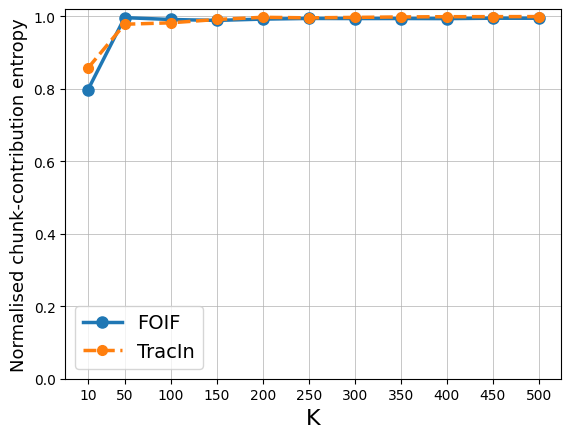

In [50]:
plt.figure()
plt.plot(k_lists, IF_Entropy_k_at_10000, "-o", label = "FOIF",linewidth=2.5,markersize=8)
plt.plot(k_lists, TC_Entropy_k_at_10000, "--o", label = "TracIn",linewidth=2.5,markersize=7)
plt.xlabel("K", fontsize=16)
plt.ylabel("Normalised chunk-contribution entropy", fontsize=13)

plt.legend(fontsize=14, loc="lower left")
plt.xticks(k_lists)
plt.ylim(0, 1.02)
plt.grid(True, linewidth=0.5)

plt.savefig(
    "Normalised_Entropy_FOIF_TracIn.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()